<hr style="height:10px"> 
 
<div class='container2'>
		<div>
			<img src='img_livro.png' ALIGN='left' style='width:10em'>
		</div>	
	<div style='padding: 0 7em 2em 12em;'>
	<h1>Inteligência Artificial: Uma Abordagem de Aprendizado de Máquina</h1>
    <h3> <a href="http://lattes.cnpq.br/4451540730749377">Katti Faceli</a> &#x25CF; <a href="http://lattes.cnpq.br/3451628262694747">Ana Carolina Lorena</a> &#x25CF; <a href="https://scholar.google.com/citations?user=jjoTZfoAAAAJ&hl=en">João Gama</a> &#x25CF; <a href="http://lattes.cnpq.br/5368680512020633">Tiago Agostinho de Almeida</a> &#x25CF; <a href="http://lattes.cnpq.br/9674541381385819">André C. P. L. F. de Carvalho</a></h3><br>
	<div style="font-size:12pt;float:left;"><b>ISBN:</b> 978-85-216-3920-6 | <b>Edição:</b> 3/2025 | <b>Editora:</b> LTC </div><br><br>
    <div style="font-size:12pt;float:left;"><b>Copyright &copy; 2025 LTC Editora. Todos os direitos reservados.</b></div>
	</div>
</div>



 <hr style="height:5px"> 

    
<h2>Métodos conexionistas</h2>

Notebook desenvolvido por: <a href="http://lattes.cnpq.br/2532893661927339">Renato Moraes Silva</a> e <a href="http://lattes.cnpq.br/4012668928932051">Pedro Reis Pires</a>   

 <hr style="height:2px"> 


## Introdução

Este notebook explora métodos conexionistas, com foco no método Perceptron Multicamadas (MLP -- *Multi-Layer Perceptron*), um dos mais tradicionais tipos de redes neurais artificiais. O MLP é amplamente utilizado para tarefas de classificação devido à sua capacidade de aprender representações complexas dos dados. Através da combinação de múltiplas camadas de neurônios artificiais e funções de ativação não lineares, ele consegue modelar padrões que métodos lineares não são capazes de capturar.

Serão realizados experimentos com uma amostragem da base de dados MNIST [1], disponível na pasta datasets e também no link: https://archive.ics.uci.edu/dataset/683/mnist+database+of+handwritten+digits. Na amostragem usada neste notebook, cada imagem tem dimensão de 28 x 28 pixels e cada pixel é representado por um valor inteiro com a intensidade do tom de cinza naquela região. O conjunto de dados contém 5.000 amostras dos dígitos de 0 a 9.

Ao final deste notebook, espera-se que o leitor compreenda como implementar uma rede neural MLP. 

Este notebook se refere aos conceitos abordados no Capítulos **7 (Métodos Conexionistas)**.

---
## Recursos Necessários

Para este *notebook*, deve ser utilizado o `Python 3.5` ou superior com as seguintes bibliotecas externas, que deverão ser instaladas:

* [`matplotlib`](https://matplotlib.org/) (versão 3.5.3 ou superior): construção e exibição de gráficos variados;
* [`numpy`](https://numpy.org) (versão 1.24.3 ou superior): manipulação de dados em formato de vetores e matrizes;
* [`pandas`](https://pandas.pydata.org/pandas-docs/stable/index.html) (versão 0.24.1 ou superior): manipulação de dados em formato de tabelas
* [`scikit-learn`](https://scikit-learn.org/stable/) (versão 1.3.0 ou superior): conjunto de métodos e modelos úteis para Aprendizado de Máquina e Inteligência Artificial;
* [`tensorflow`](https://www.tensorflow.org/) (versão 2.17.0 ou superior): conjunto de métodos e modelos úteis para Aprendizado de Máquina e Inteligência Artificial;
* [`opencv`](https://opencv.org/) (versão 4.10.0.84 ou superior): manipulação de imagens.

Será utilizado também o conjuntos de dados disponibilizado junto com este *notebook*, que se encontra no diretório `datasets`.

---
## Carregando os dados

Primeiro, iremos importar todas as bibliotecas que serão usadas ao longo deste notebook.

In [1]:
# -*- coding: utf-8 -*-

import numpy as np  # biblioteca usada para trabalhar com vetores e matrizes
import pandas as pd # biblioteca usada para trabalhar com dataframes e análise de dados
import sklearn as skl # biblioteca de aprendizado de máquina
from sklearn import model_selection 

import os # biblioteca usada para realizar tarefas específicas ao sistema operacional
import cv2 # biblioteca para manipulação de imagens

import tensorflow as tf # biblioteca de aprendizado de máquina
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import L2
from tensorflow.keras.layers import Dropout

2024-10-19 15:46:40.103607: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-19 15:46:40.135982: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-19 15:46:40.147192: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-19 15:46:40.172404: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-19 15:46:43.276382: W tensorflow/compiler/tf2

Em seguida, iremos carregar os dados que serão utilizados ao longo do notebook.

In [2]:
def importDataset(path):
    
    # Percorre as pastas e coleta as imagens 
    labelList = []
    imgList = []
    
    for i in range(0,10):

        print("Folder: %d" %i)
         
        # Coleta os nomes dos arquivos da pasta
        files = os.listdir(path + str(i) )

        for file in files:

            # Abre a imagem
            imgPath = os.path.join(path, str(i), file)
            img = cv2.imread( imgPath, cv2.IMREAD_GRAYSCALE)
            
            imgList.append(img)
            
            # guarda a classe da imagem
            labelList.append(i)
    
    return imgList, labelList

# Caminho dos arquivos
path = "datasets/MNIST/"

imgList, labelList = importDataset(path)       
    
print('\nQuantidade de imagens: ', len(imgList))

print("\nDimensão da primeira imagem")
imgList[0].shape

Folder: 0
Folder: 1
Folder: 2
Folder: 3
Folder: 4
Folder: 5
Folder: 6
Folder: 7
Folder: 8
Folder: 9

Quantidade de imagens:  5000

Dimensão da primeira imagem


(28, 28)

As imagens e as classes foram guardadas em uma lista. Para trabalhar melhor com os dados, vamos converter as imagens em uma matriz, onde cada linha representará uma imagem. Também converteremos a lista de classes em um vetor. 

In [3]:
for i, img in enumerate(imgList):
    
    # Transforma a matriz que representa a imagem em um vetor 
    imgList[i] = np.ravel( imgList[i] ) 
    
# Converte a lista de imagens em uma matriz
X_img = np.asarray( imgList )

# Converte a lista de classes em um vetor
Y = np.asarray( labelList )
        
print('\nDimensao de X: ', X_img.shape)

print('\nDimensao de Y: ', Y.shape)

print('\nClasses do problema: ', np.unique(Y))


Dimensao de X:  (5000, 784)

Dimensao de Y:  (5000,)

Classes do problema:  [0 1 2 3 4 5 6 7 8 9]


Os tons de cinza são representados por valores entre 0 e 255. Esse formato de valores não é adequado para métodos de classificação baseados em otimização, pois valores grandes podem afetar o desempenho dos algoritmos. Por isso, iremos normalizar esses valores para o intervalo entre 0 e 1. Para isso, basta dividir por 255.

**Importante**: essa normalização é adequada para este exemplo simples, onde os valores representam pixels de imagem. Em problemas mais complexos, pode ser preferível adotar métodos mais robustos, como a normalização *z-score*. 

In [4]:
X = X_img/255.0

print('Maior valor de X: %1.10f' %np.max(X))
print('Menor valor de X: %1.10f' %np.min(X))

Maior valor de X: 1.0000000000
Menor valor de X: 0.0000000000


Vamos visualizar aleatoriamente 100 amostras da base de dados.

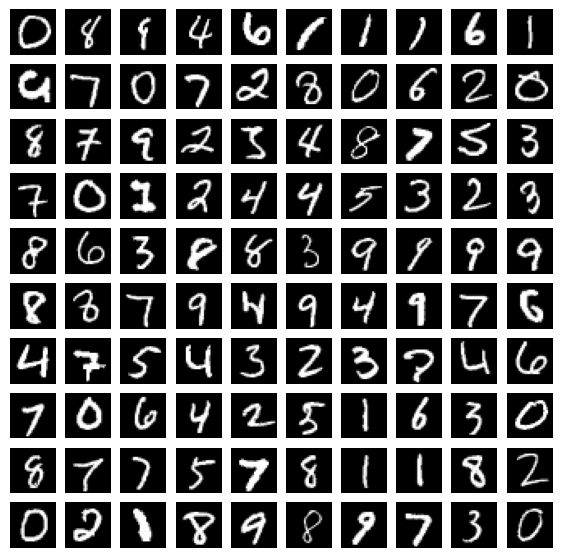

In [5]:
import matplotlib.pyplot as plt

def visualizaDados(X):
    
    # Calcula numero de linhas e colunas
    m, n = X.shape
    
    # calcula a largura das imagens
    example_width = int(round(np.sqrt(n)) )
    example_height = int(n / example_width)

    # Calcula numero de itens que serao exibidos
    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, axs = plt.subplots(display_rows,display_cols, figsize=(7, 7))
                        
    for ax, i in zip(axs.ravel(), range( X.shape[0] )):
    
        new_X = np.reshape( np.ravel(X[i,:]), (example_width, example_height) )

        ax.imshow(new_X, cmap='gray'); 
        ax.axis('off')
    
    plt.show()

# Gera índices aleatórios
idx_perm = np.random.RandomState(seed=10).permutation( range(X.shape[0]) )

# Exibe as imagens
visualizaDados( X[idx_perm[0:100],:] )

---
## Implementando a rede neural

Antes de implementar a rede neural, iremos separar os dados em dois conjuntos: treino (80%) e teste (20%).

In [6]:
# Separa em treino e teste de maneira estratificada 
cv = skl.model_selection.StratifiedShuffleSplit(n_splits=1, train_size=0.8, random_state=20)

train_index, test_index = next(cv.split(X, Y))

X_train, X_test = X[train_index], X[test_index]
Y_train, Y_test = Y[train_index], Y[test_index]

print('Qtd. dados de treinamento: %d (%1.2f%%)' %(X_train.shape[0], (X_train.shape[0]/X.shape[0])*100) )
print('Qtd. de dados de teste: %d (%1.2f%%)' %(X_test.shape[0], (X_test.shape[0]/X.shape[0])*100) )

Qtd. dados de treinamento: 4000 (80.00%)
Qtd. de dados de teste: 1000 (20.00%)


Iremos definir a arquitetura da rede neural contendo tem 3 camadas: uma camada de entrada, uma camada oculta e uma camada de saída. A camada de entrada possui 784 neurônios que corresponde ao total de pixels de cada imagem. 

Essa arquitetura simples foi adotada apenas para facilitar o entendimento. Você pode definir arquiteturas mais complexas. 

Iremos carregar os parâmetros que serão usados na arquitetura da rede neural.

In [7]:
# parametros a serem utilizados 
input_layer_size  = 28*28  # 28x28: dimensao das imagens de entrada
hidden_layer_size = 100   # 25 neuronios na camada oculta
num_labels = len( np.unique(Y) ) # calcula a quantidade de classes      

Existem diversas bibliotecas em Python para implementação de MLPs e outros tipos de redes neurais. Neste notebook, iremos usar a biblioteca **tensorflow**. Como o nosso problema é de classificação multiclasse, precisaremos fazer a conversão das classes para o formato binário. Espera-se vetores com $|C|$ (onde, $|C|$ é o número de classes) posições contendo 1 para o elemento referente à classe esperada e 0 nos demais elementos. Por exemplo, seja 5 o rótulo de determinada amostra, o vetor $Y$ correspondente terá 1 na posição $y_5$ e 0 nas demais posições.

In [8]:
# converte as classes para o formato binário
def converteBinario(Y, num_labels):
    m = len(Y)
    
    # variavel que irá ser retornada
    Y_bin = None
    
    Y_bin = np.zeros([m,num_labels], dtype=int)
    for i in range(m):
        Y_bin[i,Y[i]] = 1
          
    return Y_bin

# chama a funca que ira converter em binario
Y_trainBin = converteBinario(Y_train, num_labels)

print("Cinco primeiras classes: ")
print(Y_trainBin[0:5, :])

Cinco primeiras classes: 
[[1 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]]


Agora, iremos configurar a rede neural.

In [9]:
# Ajusta a camada de entrada
input_shape = (input_layer_size,)
print('Camada de entrada: ', input_shape)

# Configura o modelo de rede neural artificial
model = Sequential()

# Camada de entrada
model.add(tf.keras.Input(shape=(input_layer_size,)))

# Camada intermediária
model.add(Dense(hidden_layer_size, activation='sigmoid'))

# Camada de saída
model.add(Dense(num_labels, activation='sigmoid'))

# Finaliza  configuração do modelo e inicia o treinamento
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1)

# Configura o modelo para o treinamento
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Inicia o treinamento
history = model.fit(X_train, Y_trainBin, epochs=500, batch_size=250, validation_split=0.2, verbose=0)

print(model.summary())

Camada de entrada:  (784,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,512 (310.60 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

None


Vamos exibir a evolução do erro. 

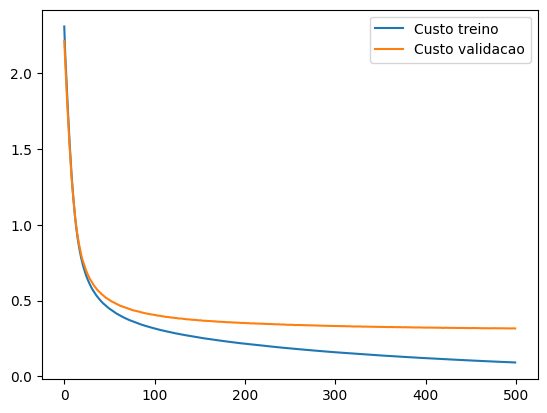

In [10]:
import pandas as pd

df = pd.DataFrame()
df['Custo treino'] = history.history['loss']
df['Custo validacao'] = history.history['val_loss']

df.plot()
plt.show()

**Calculando o desempenho nos dados de teste** 

Vamos testar o modelo nos dados de teste. 

In [11]:
import sklearn as skl
import sklearn.metrics

def predicao(model, X_test, Y_test, num_labels):
    """
    Retorna as classes preditas e a acurácia
    """
    
    # variaveis que precisam ser calculadas
    predClass = None 
    acuracia = 0.0

    # converte os dados de teste para o formato binario
    Y_testBin = converteBinario(Y_test, num_labels)

    test_results = model.evaluate(X_test, Y_testBin, verbose=0)
    acuracia = test_results[1]

    # obtem a probabilidade de cada classe
    pred = model.predict(X_test)

    # pega o índice que obteve a maior probabilidade
    predClass = np.argmax(pred, axis=1)

    return predClass, acuracia


# obtem as classes
predClass, acuracia = predicao(model, X_test, Y_test, num_labels)

print('Acuracia: %1.3f' %acuracia)
    
    
# obtem as medidas de desempenho
resultados = skl.metrics.classification_report(Y_test, predClass)
    
print(resultados)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Acuracia: 0.905
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       100
           1       0.92      0.97      0.95       100
           2       0.92      0.89      0.90       100
           3       0.86      0.87      0.87       100
           4       0.88      0.92      0.90       100
           5       0.88      0.90      0.89       100
           6       0.94      0.92      0.93       100
           7       0.91      0.90      0.90       100
           8       0.90      0.82      0.86       100
           9       0.89      0.88      0.88       100

    accuracy                           0.91      1000
   macro avg       0.90      0.91      0.90      1000
weighted avg       0.90      0.91      0.90      1000



---
## Rede neural com regularização e mais camadas

Nesta etapa, vamos modificar a rede neural anterior acrescentando regularização (L2 e *dropout*), mais camadas e modificando a quantidade de neurônios em cada camada, a função de ativação e o método de otimização. Com isso, poderemos entender melhor o funcionamento das redes neurais multicamadas.

In [18]:
# regularizacao
regularizacao = tf.keras.regularizers.L2(0.001)

# ajusta a camada de entrada
input_shape = (input_layer_size,)
print('Camada de entrada: ', input_shape)

# Configura o modelo de rede neural artificial
model = Sequential()
model.add(tf.keras.Input(shape=(input_layer_size,)))

model.add(Dense(hidden_layer_size,
                activity_regularizer = regularizacao, 
                activation='relu'))

model.add(Dropout(0.05))

model.add(Dense(num_labels, activation='softmax'))

# Finaliza  configuração do modelo e inicia o treinamento
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# inicia o treinamento
history = model.fit(X_train, Y_trainBin, epochs=500, batch_size=250, validation_split=0.2, verbose=0)

print(model.summary())

Camada de entrada:  (784,)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,532 (931.77 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 159,022 (621.18 KB)

None


Iremos exibir a evolução do erro. 

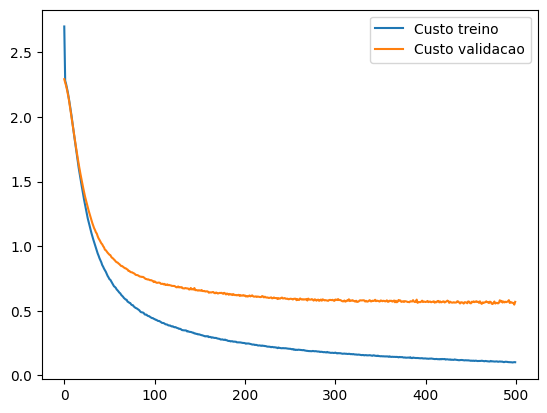

In [19]:
import pandas as pd
df = pd.DataFrame()
df['Custo treino'] = history.history['loss']
df['Custo validacao'] = history.history['val_loss']

df.plot()
plt.show()

**Calculando o desempenho nos dados de teste** 

Vamos testar o modelo nos dados de teste. 

In [20]:
# obtem as classes
predClass, acuracia = predicao(model, X_test, Y_test, num_labels)

print('Acuracia: %1.3f' %acuracia)
    
    
# obtem as medidas de desempenho
resultados = skl.metrics.classification_report(Y_test, predClass)

print(resultados)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Acuracia: 0.859
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       100
           1       0.94      0.96      0.95       100
           2       0.92      0.80      0.86       100
           3       0.83      0.81      0.82       100
           4       0.87      0.83      0.85       100
           5       0.88      0.79      0.83       100
           6       0.88      0.90      0.89       100
           7       0.87      0.90      0.88       100
           8       0.71      0.85      0.77       100
           9       0.81      0.80      0.80       100

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000



Uma rede neural é sensível à escolha de seus parâmetros. Nos modelos treinados acima, os parâmetros foram selecionados com o propósito de demonstrar o funcionamento básico das redes. No entanto, é recomendável que em outros problemas diferentes combinações de parâmetros sejam testadas, assim como outras arquiteturas, variando o número de camadas intermediárias e a quantidade de neurônios em cada camada. Esse processo de ajuste fino é fundamental para otimizar o desempenho da rede em diferentes problemas e pode levar a resultados melhores.

---
## Conclusão

Neste notebook, foram apresentadas as principais etapas do processo de classificação de dígitos numéricos usando a rede neural MLP. Foi explorada uma arquitetura clássica de MLP, utilizando a função de ativação sigmoidal, uma das mais tradicionais, e uma única camada intermediária. Também foram mostradas algumas configurações adicionais, como o uso da função de ativação ReLU (do inglês, *Rectified Linear Unit*), bastante adotada nas camadas intermediárias de modelos modernos, e da função softmax na camada de saída para a classificação de múltiplas classes. Também foi incluída a técnica de *dropout* e da função de otimização Adam (do inglês, *Adaptive Moment Estimation*).

---
## Referências

[1] Y. LeCun, L. Bottou, Y. Bengio, and P. Haffner. Gradient-based learning applied to document recognition.  Proceedings of the IEEE, vol. 86, no. 11, pp. 2278-2324, Nov. 1998. DOI: [10.1109/5.726791](http://dx.doi.org/10.1109/5.726791).